# RQ1 --- Effectiveness

In [3]:
import sys

sys.path.insert(0, "..")
import numpy as np
from experiments._loader import load_all_results, success_only
from experiments._analysis import (
    PALETTE,
    tex,
    setup_matplotlib,
    compute_image_metrics,
    compute_text_metrics,
    classify_termination_series,
    TERMINATION_COLORS,
    TERMINATION_ORDER,
)
import matplotlib.pyplot as plt

setup_matplotlib()

df_all = load_all_results(include_baseline_fail=True)
df_opt = success_only(df_all)

THRESHOLDS = np.arange(0.0, 1.1, 0.1)  # 0.0, 0.1, ..., 0.9

MODEL_MAPPING = {
    "qwen": "Qwen3-VL",
    "kimi": "Kimi-VL",
    "intern": "InternVL3.5",
    "gemma": "Gemma3",
    "deepseek": "DeepseekVL2",
    "nemotron": "Nemotron3-NO",
}

In [22]:
# ============================================================
# Joint-vs-Uni-modal analysis over ALL AVAILABLE IMAGES
#
# - No filename pairing
# - Independent bootstrap CIs
# - Fisher exact tests
# - Holm multiple-testing correction
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

THRESHOLD = 0.25
N_BOOT = 10_000
RANDOM_SEED = 42

GENOME_MODES = ["multi", "image", "text"]

# Only final retained models
RETAINED_MODELS = [
    "intern",
    "kimi",
    "nemotron",
    "qwen",
]

SCENE_LABELS = {
    "multi": "MC",
    "single/multi": "SC-MI",
    "single/solo": "SC-SI",
    "udacity": "Driving",
}

SCENE_ORDER = [
    "MC",
    "SC-MI",
    "SC-SI",
    "Driving",
]


# ------------------------------------------------------------
# 1. Prepare analysis population
# ------------------------------------------------------------

analysis = df_all[
    df_all["model"].isin(RETAINED_MODELS)
    & df_all["obj_category"].notna()
    & df_all["genome_mode"].isin(GENOME_MODES)
].copy()


# Exclude baseline failures.
#
# Importantly, we do NOT require the same filename to occur
# under all three regimes.
analysis = analysis[
    analysis["status"] != "baseline_fail"
].copy()


# Binary threshold-reaching outcome.
#
# If final_iou is unavailable (e.g., malformed output / no object),
# the run did not reach the IoU threshold and is counted as 0.
analysis["success"] = (
    analysis["final_iou"].notna()
    & (analysis["final_iou"] <= THRESHOLD)
).astype(int)


analysis["scene"] = (
    analysis["obj_category"]
    .map(SCENE_LABELS)
)


# ------------------------------------------------------------
# 2. Summarize ASR independently for each regime
# ------------------------------------------------------------

mode_summary = (
    analysis
    .groupby(
        ["model", "obj_category", "scene", "genome_mode"],
        dropna=False,
    )
    .agg(
        n=("success", "size"),
        successes=("success", "sum"),
        asr=("success", "mean"),
    )
    .reset_index()
)


# ------------------------------------------------------------
# 3. Convert to one row per model x scene
# ------------------------------------------------------------

records = []

for (model, obj_category, scene), group in mode_summary.groupby(
    ["model", "obj_category", "scene"],
    dropna=False,
):

    by_mode = group.set_index("genome_mode")

    # Require data for all three regimes.
    if not all(mode in by_mode.index for mode in GENOME_MODES):
        continue

    asr_multi = by_mode.loc["multi", "asr"]
    asr_image = by_mode.loc["image", "asr"]
    asr_text = by_mode.loc["text", "asr"]

    best_unimodal = max(
        asr_image,
        asr_text,
    )

    best_unimodal_mode = (
        "image"
        if asr_image >= asr_text
        else "text"
    )

    records.append({
        "model": model,
        "obj_category": obj_category,
        "scene": scene,

        "n_multi": int(by_mode.loc["multi", "n"]),
        "n_image": int(by_mode.loc["image", "n"]),
        "n_text": int(by_mode.loc["text", "n"]),

        "success_multi": int(
            by_mode.loc["multi", "successes"]
        ),
        "success_image": int(
            by_mode.loc["image", "successes"]
        ),
        "success_text": int(
            by_mode.loc["text", "successes"]
        ),

        "asr_multi": asr_multi,
        "asr_image": asr_image,
        "asr_text": asr_text,

        "best_unimodal": best_unimodal,
        "best_unimodal_mode": best_unimodal_mode,

        "delta_joint": (
            asr_multi - best_unimodal
        ),
    })


joint_results = pd.DataFrame(records)


# ------------------------------------------------------------
# 4. Independent bootstrap CI for joint advantage
# ------------------------------------------------------------

def bootstrap_joint_independent(
    multi,
    image,
    text,
    n_boot=10_000,
    random_seed=42,
):
    """
    Bootstrap each regime independently.

    Returns CI for:
        ASR_multi - max(ASR_image, ASR_text)
    """

    rng = np.random.default_rng(random_seed)

    multi = np.asarray(multi, dtype=int)
    image = np.asarray(image, dtype=int)
    text = np.asarray(text, dtype=int)

    observed = (
        multi.mean()
        - max(
            image.mean(),
            text.mean(),
        )
    )

    boot = np.empty(n_boot)

    for i in range(n_boot):

        multi_b = rng.choice(
            multi,
            size=len(multi),
            replace=True,
        )

        image_b = rng.choice(
            image,
            size=len(image),
            replace=True,
        )

        text_b = rng.choice(
            text,
            size=len(text),
            replace=True,
        )

        boot[i] = (
            multi_b.mean()
            - max(
                image_b.mean(),
                text_b.mean(),
            )
        )

    ci_low, ci_high = np.percentile(
        boot,
        [2.5, 97.5],
    )

    return observed, ci_low, ci_high


bootstrap_records = []

for (model, obj_category, scene), group in analysis.groupby(
    ["model", "obj_category", "scene"],
    dropna=False,
):

    values = {}

    for mode in GENOME_MODES:
        values[mode] = (
            group.loc[
                group["genome_mode"] == mode,
                "success",
            ]
            .dropna()
            .to_numpy()
        )

    if any(len(values[m]) == 0 for m in GENOME_MODES):
        continue

    observed, ci_low, ci_high = bootstrap_joint_independent(
        values["multi"],
        values["image"],
        values["text"],
        n_boot=N_BOOT,
        random_seed=RANDOM_SEED,
    )

    bootstrap_records.append({
        "model": model,
        "obj_category": obj_category,
        "scene": scene,
        "delta_joint_boot": observed,
        "ci_low": ci_low,
        "ci_high": ci_high,
    })


bootstrap_df = pd.DataFrame(
    bootstrap_records
)

joint_results = joint_results.merge(
    bootstrap_df,
    on=[
        "model",
        "obj_category",
        "scene",
    ],
    how="left",
)


# ------------------------------------------------------------
# 5. Fisher exact tests
#
# Compare:
#   multi vs image
#   multi vs text
#
# Each test compares the proportion of successful attacks.
# ------------------------------------------------------------

test_records = []

for (model, obj_category, scene), group in analysis.groupby(
    ["model", "obj_category", "scene"],
    dropna=False,
):

    multi = group[
        group["genome_mode"] == "multi"
    ]["success"]

    if multi.empty:
        continue

    for comparator in ["image", "text"]:

        other = group[
            group["genome_mode"] == comparator
        ]["success"]

        if other.empty:
            continue

        multi_success = int(multi.sum())
        multi_fail = int(
            len(multi) - multi_success
        )

        other_success = int(other.sum())
        other_fail = int(
            len(other) - other_success
        )

        # Rows = manipulation regime
        # Columns = success / failure
        table = np.array([
            [multi_success, multi_fail],
            [other_success, other_fail],
        ])

        odds_ratio, p_raw = fisher_exact(
            table,
            alternative="two-sided",
        )

        test_records.append({
            "model": model,
            "obj_category": obj_category,
            "scene": scene,
            "comparison": f"multi_vs_{comparator}",

            "n_multi": len(multi),
            "n_other": len(other),

            "asr_multi": multi.mean(),
            "asr_other": other.mean(),

            "difference": (
                multi.mean()
                - other.mean()
            ),

            "odds_ratio": odds_ratio,
            "p_raw": p_raw,
        })


tests = pd.DataFrame(
    test_records
)


# ------------------------------------------------------------
# 6. Holm correction
# ------------------------------------------------------------

if not tests.empty:

    tests["p_holm"] = multipletests(
        tests["p_raw"],
        method="holm",
    )[1]

    tests["significant_05"] = (
        tests["p_holm"] < 0.05
    )


# ------------------------------------------------------------
# 7. Merge corrected p-values into joint results
# ------------------------------------------------------------

if not tests.empty:

    test_wide = (
        tests
        .pivot_table(
            index=[
                "model",
                "obj_category",
                "scene",
            ],
            columns="comparison",
            values="p_holm",
        )
        .reset_index()
    )

    joint_results = joint_results.merge(
        test_wide,
        on=[
            "model",
            "obj_category",
            "scene",
        ],
        how="left",
    )


# ------------------------------------------------------------
# 8. CI interpretation
# ------------------------------------------------------------

joint_results["ci_excludes_zero"] = (
    (joint_results["ci_low"] > 0)
    | (joint_results["ci_high"] < 0)
)


joint_results["joint_direction"] = np.select(
    [
        joint_results["ci_low"] > 0,
        joint_results["ci_high"] < 0,
    ],
    [
        "joint higher",
        "best unimodal higher",
    ],
    default="no clear difference",
)


# ------------------------------------------------------------
# 9. Paper-friendly sorting
# ------------------------------------------------------------

joint_results["scene"] = pd.Categorical(
    joint_results["scene"],
    categories=SCENE_ORDER,
    ordered=True,
)

tests["scene"] = pd.Categorical(
    tests["scene"],
    categories=SCENE_ORDER,
    ordered=True,
)


joint_results = (
    joint_results
    .sort_values(
        ["model", "scene"]
    )
    .reset_index(drop=True)
)


tests = (
    tests
    .sort_values(
        [
            "model",
            "scene",
            "comparison",
        ]
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 10. Display
# ------------------------------------------------------------

cols = [
    "model",
    "scene",

    "n_image",
    "n_text",
    "n_multi",

    "asr_image",
    "asr_text",
    "asr_multi",

    "best_unimodal",
    "best_unimodal_mode",

    "delta_joint",
    "ci_low",
    "ci_high",

    "multi_vs_image",
    "multi_vs_text",

    "joint_direction",
]


display(
    joint_results[
        [c for c in cols if c in joint_results.columns]
    ].round(4)
)


print("\nHolm-corrected Fisher exact tests:")

display(
    tests.round(4)
)

,model,scene,n_image,n_text,n_multi,asr_image,asr_text,asr_multi,best_unimodal,best_unimodal_mode,delta_joint,ci_low,ci_high,multi_vs_image,multi_vs_text,joint_direction
0,intern,MC,52,52,52,0.7692,0.8077,0.8462,0.8077,text,0.0385,-0.1154,0.1538,1.0000,1.000,no clear difference
1,intern,SC-MI,42,42,42,0.8571,0.9286,0.9524,0.9286,text,0.0238,-0.0714,0.1190,1.0000,1.000,no clear difference
2,intern,SC-SI,32,32,32,0.7812,0.9062,0.9688,0.9062,text,0.0625,-0.0625,0.1875,1.0000,1.000,no clear difference
3,intern,Driving,6,6,6,1.0000,1.0000,0.8333,1.0000,image,-0.1667,-0.5000,0.0000,1.0000,1.000,no clear difference
4,kimi,MC,25,25,25,0.8000,0.9600,0.9200,0.9600,text,-0.0400,-0.1600,0.0800,1.0000,1.000,no clear difference
5,kimi,SC-MI,13,13,13,0.7692,0.9231,0.6923,0.9231,text,-0.2308,-0.5385,0.0000,1.0000,1.000,no clear difference
6,kimi,SC-SI,52,52,52,0.8462,0.9231,0.9231,0.9231,text,0.0000,-0.0962,0.0962,1.0000,1.000,no clear difference
7,kimi,Driving,20,20,20,1.0000,1.0000,1.0000,1.0000,image,0.0000,0.0000,0.0000,1.0000,1.000,no clear difference
8,nemotron,MC,41,41,41,0.3171,0.4878,0.4390,0.4878,text,-0.0488,-0.2683,0.1463,1.0000,1.000,no clear difference
9,nemotron,SC-MI,12,12,12,0.5000,0.9167,0.9167,0.9167,text,0.0000,-0.2500,0.2500,1.0000,1.000,no clear difference



Holm-corrected Fisher exact tests:


,model,obj_category,scene,comparison,n_multi,n_other,asr_multi,asr_other,difference,odds_ratio,p_raw,p_holm,significant_05
0,intern,multi,MC,multi_vs_image,52,52,0.8462,0.7692,0.0769,1.6500,0.4561,1.0000,False
1,intern,multi,MC,multi_vs_text,52,52,0.8462,0.8077,0.0385,1.3095,0.7961,1.0000,False
2,intern,single/multi,SC-MI,multi_vs_image,42,42,0.9524,0.8571,0.0952,3.3333,0.2646,1.0000,False
3,intern,single/multi,SC-MI,multi_vs_text,42,42,0.9524,0.9286,0.0238,1.5385,1.0000,1.0000,False
4,intern,single/solo,SC-SI,multi_vs_image,32,32,0.9688,0.7812,0.1875,8.6800,0.0534,1.0000,False
5,intern,single/solo,SC-SI,multi_vs_text,32,32,0.9688,0.9062,0.0625,3.2069,0.6128,1.0000,False
6,intern,udacity,Driving,multi_vs_image,6,6,0.8333,1.0000,-0.1667,0.0000,1.0000,1.0000,False
7,intern,udacity,Driving,multi_vs_text,6,6,0.8333,1.0000,-0.1667,0.0000,1.0000,1.0000,False
8,kimi,multi,MC,multi_vs_image,25,25,0.9200,0.8000,0.1200,2.8750,0.4174,1.0000,False
9,kimi,multi,MC,multi_vs_text,25,25,0.9200,0.9600,-0.0400,0.4792,1.0000,1.0000,False


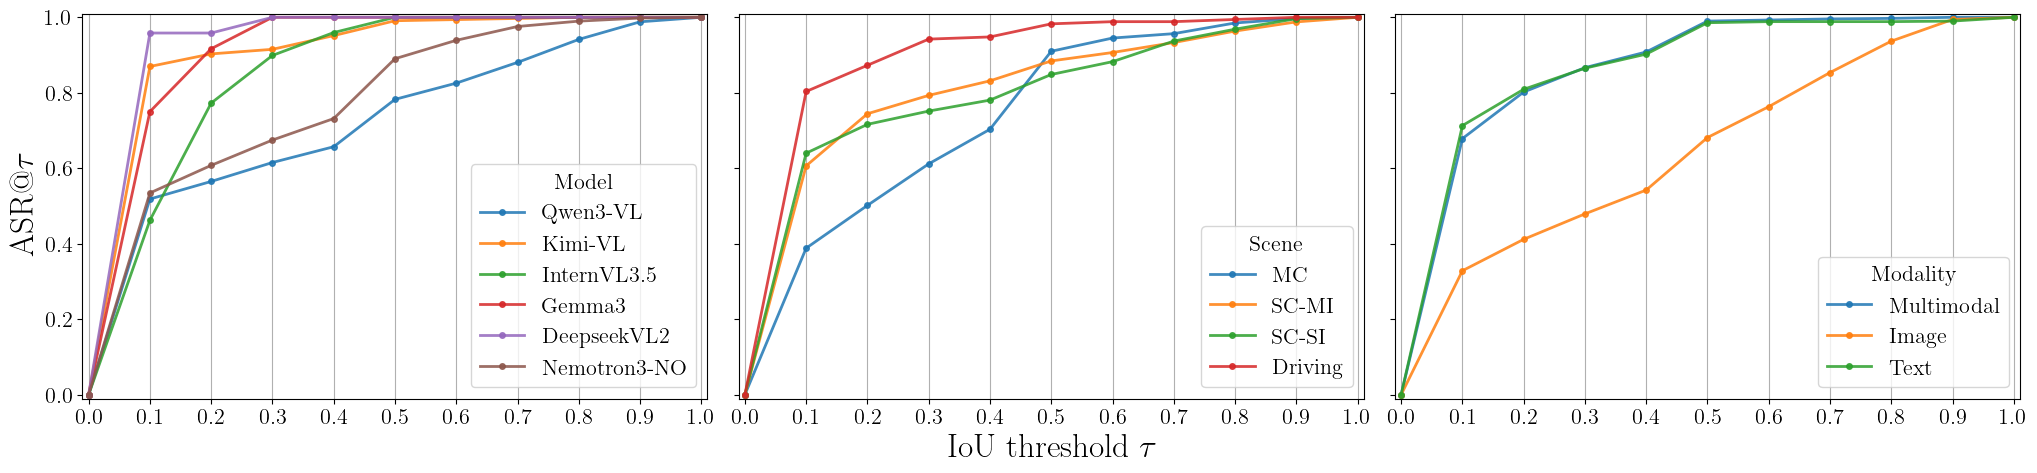

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(25, 5), sharey=True)
fig.subplots_adjust(wspace=0.05)

# 1) By model
ax = axes[0]

for i, (model, alias) in enumerate(MODEL_MAPPING.items()):
    sub = df_opt[df_opt["model"] == model]
    if df_opt[df_opt["model"] == model].size < 30:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=tex(alias),
        color=PALETTE[i],
        alpha=0.85,
        marker="o",
        markersize=4,
    )
##ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_ylabel(r"ASR@$\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Model")
ax.grid(axis="x")

# 2) By scene
SCENE_ALIAS = {
    "multi": "MC",
    "single/multi": "SC-MI",
    "single/solo": "SC-SI",
    "udacity": "Driving"
}

ax = axes[1]
for scene, label in SCENE_ALIAS.items():
    sub = df_opt[df_opt["obj_category"] == scene]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
ax.set_xlabel(r"IoU threshold $\tau$", fontsize=24)
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Scene")
ax.grid(axis="x")

# 3) By modality
MODALITY_ALIAS = {
    "multi": "Multimodal",
    "image": "Image",
    "text": "Text",
}

ax = axes[2]
for modality, label in MODALITY_ALIAS.items():
    sub = df_opt[df_opt["genome_mode"] == modality]
    if sub.empty:
        continue
    ax.plot(
        THRESHOLDS,
        [(sub["final_iou"] < t).mean() for t in THRESHOLDS],
        lw=2,
        label=label,
        alpha=0.85,
        marker="o",
        markersize=4,
    )
# ax.set_xlabel(r'IoU threshold $\tau$')
ax.set_xticks(THRESHOLDS)
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.legend(title="Modality")
ax.grid(axis="x")
plt.savefig("figures/curves_rq1.pdf", dpi=200, bbox_inches="tight")

In [8]:
df_opt = compute_image_metrics(df_opt)

df_txt = compute_text_metrics(df_opt[df_opt["genome_mode"].isin(["multi", "text"])].copy())

SCENES = [
    ("MC", "multi"),
    ("SC-MI", "single/multi"),
    ("SC-SI", "single/solo"),
    ("Driving", "udacity"),
]

GENOME_MODES = [
    "multi",
    "image",
    "text",
]


def format_mean_std(
    mean: float,
    std: float,
    decimals: int = 2,
) -> str:
    if pd.isna(mean):
        return "---"

    std = 0.0 if pd.isna(std) else std
    return f"${mean:.{decimals}f} \\pm {std:.{decimals}f}$"


records = []

for model in sorted(df_all["model"].dropna().unique()):
    for scene, obj_category in SCENES:
        scene_all = df_all[(df_all["model"] == model) & (df_all["obj_category"] == obj_category)]

        # Baseline failure rate is shared across the three manipulations.
        fail_rate = (
            (scene_all["status"] == "baseline_fail").mean() if not scene_all.empty else np.nan
        )

        for genome_mode in GENOME_MODES:
            sub_all = scene_all[scene_all["genome_mode"] == genome_mode]

            sub_opt = df_opt[
                (df_opt["model"] == model)
                & (df_opt["genome_mode"] == genome_mode)
                & (df_opt["obj_category"] == obj_category)
            ]

            record = {
                "model": model,
                "scene": scene,
                "genome_mode": genome_mode,
                "fail_rate": f"{fail_rate:.2f}" if not pd.isna(fail_rate) else "---",
                "frac10": "---",
                "frac25": "---",
                "frac50": "---",
                "ssim": "---",
                "ned": "---",
            }

            if not sub_all.empty and fail_rate <= 0.90 and not sub_opt.empty:
                record["frac10"] = f"{(sub_opt['final_iou'] <= 0.10).mean():.2f}"
                record["frac25"] = f"{(sub_opt['final_iou'] <= 0.25).mean():.2f}"
                record["frac50"] = f"{(sub_opt['final_iou'] <= 0.50).mean():.2f}"

                if genome_mode in {"multi", "image"}:
                    ms = sub_opt["ms_ssim"].dropna()

                    if not ms.empty:
                        record["ssim"] = format_mean_std(
                            ms.mean(),
                            ms.std(),
                        )

                if genome_mode in {"multi", "text"}:
                    nd = df_txt[
                        (df_txt["model"] == model)
                        & (df_txt["genome_mode"] == genome_mode)
                        & (df_txt["obj_category"] == obj_category)
                    ]["ned"].dropna()

                    if not nd.empty:
                        record["ned"] = format_mean_std(
                            nd.mean(),
                            nd.std(),
                        )

            records.append(record)

effectiveness_df = pd.DataFrame(records)

In [13]:
effectiveness_df = pd.DataFrame(records)

In [15]:
effectiveness_df["fail_rate"] = pd.to_numeric(
    effectiveness_df["fail_rate"],
    errors="coerce",
)

effectiveness_df = effectiveness_df[
    effectiveness_df["fail_rate"] < 0.95
].copy()

In [11]:
effectiveness_df.to_csv("effectiveness.csv")

<>:64: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:64: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
<>:76: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_297292/1720540960.py:64: SyntaxWarning: invalid escape sequence '\%'
  f"{percentage:.1f}\%",
/tmp/ipykernel_297292/1720540960.py:76: SyntaxWarning: invalid escape sequence '\%'
  ["0\%", "25\%", "50\%", "75\%", "100\%"],
/tmp/ipykernel_297292/1720540960.py:76: SyntaxWarning: invalid escape sequence '\%'
  ["0\%", "25\%", "50\%", "75\%", "100\%"],
/tmp/ipykernel_297292/1

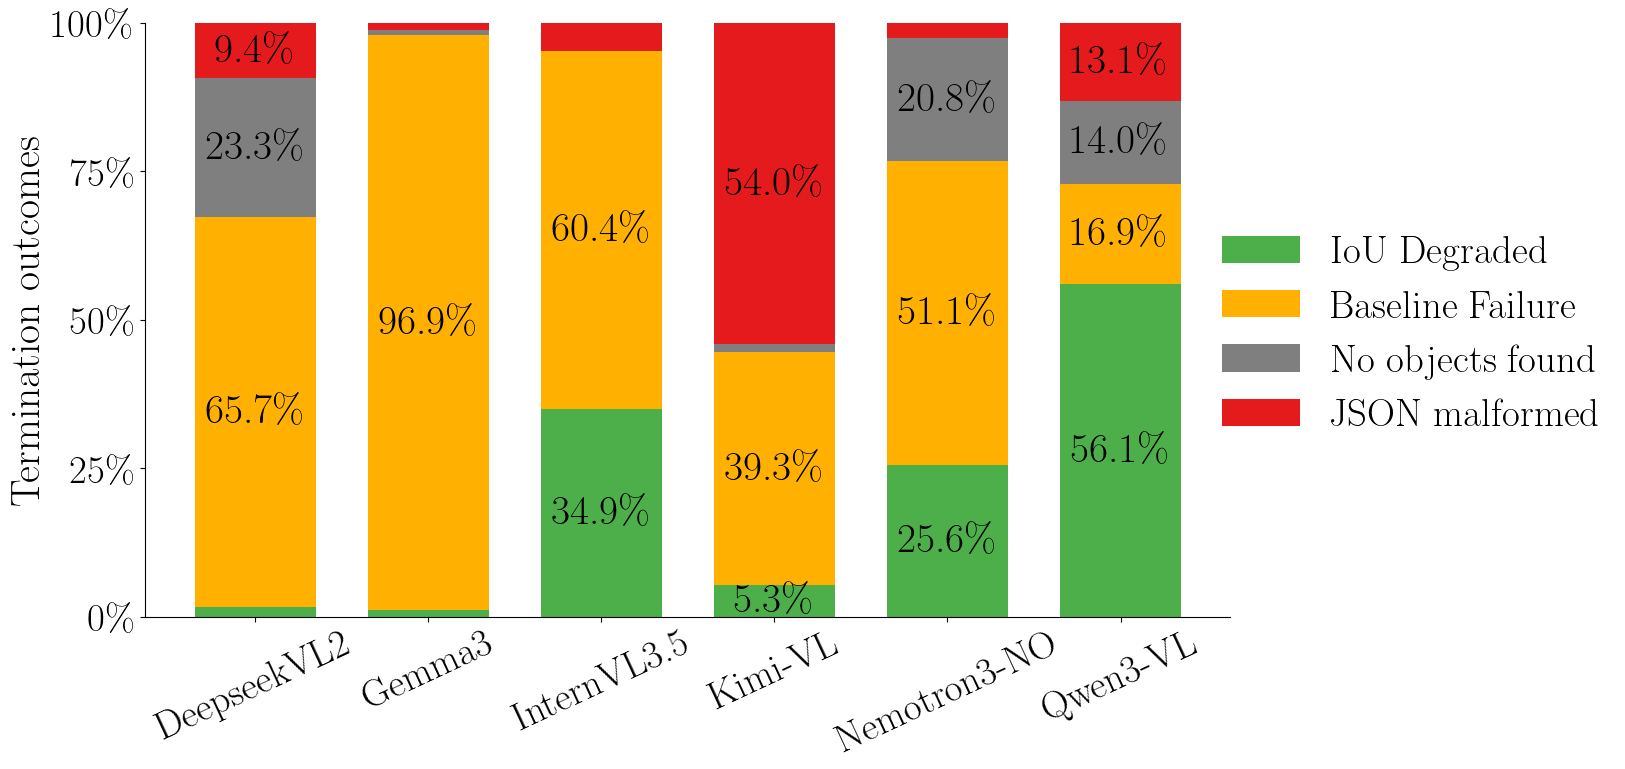

In [16]:
term_df = classify_termination_series(df_all)
term_df["termination_type"] = term_df["termination_type"].replace({
    "BBOX IoU too small": "Baseline Failure",
    "Success": "IoU Degraded",
})
models = sorted(term_df["model"].dropna().unique())

TEXT_SIZE = 30
TICK_SIZE = 28
LEGEND_SIZE = 28

fig, ax = plt.subplots(
    figsize=(14, 9)
)

x = np.arange(len(models))
bottom = np.zeros(len(models))

present_labels = [
    label
    for label in TERMINATION_ORDER
    if label in set(term_df["termination_type"].dropna())
]

for label in present_labels:

    percentages = []

    for model in models:
        sub = term_df[term_df["model"] == model]

        counts = sub["termination_type"].value_counts()
        total = counts.sum()

        value = counts.get(label, 0)

        percentage = (
            100.0 * value / total
            if total > 0
            else 0
        )

        percentages.append(percentage)

    percentages = np.array(percentages)

    bars = ax.bar(
        x,
        percentages,
        bottom=bottom,
        color=TERMINATION_COLORS[label],
        width=0.7,
        label=label,
    )

    # percentage labels inside segments
    for i, (bar, percentage) in enumerate(
        zip(bars, percentages)
    ):
        if percentage >= 5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[i] + percentage / 2,
                f"{percentage:.1f}\%",
                ha="center",
                va="center",
                fontsize=TEXT_SIZE,
            )

    bottom += percentages

ax.set_ylim(0, 100)

ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(
    ["0\%", "25\%", "50\%", "75\%", "100\%"],
    fontsize=TICK_SIZE,
)

ax.set_xticks(x)
ax.set_xticklabels(
    [tex(MODEL_MAPPING[m]) for m in models],
    fontsize=TICK_SIZE, rotation=25,
)

ax.set_ylabel(
    "Termination outcomes",
    fontsize=TEXT_SIZE,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    bbox_to_anchor=(0.96, 0.7),
    fontsize=LEGEND_SIZE,
    frameon=False,
)

fig.subplots_adjust(
    bottom=0.22,
)

plt.savefig(
    "figures/termination_bars.pdf",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

In [11]:
effectiveness_df = pd.read_csv("effectiveness.csv")

In [17]:
filtered = effectiveness_df[effectiveness_df["fail_rate"] <= 0.9]

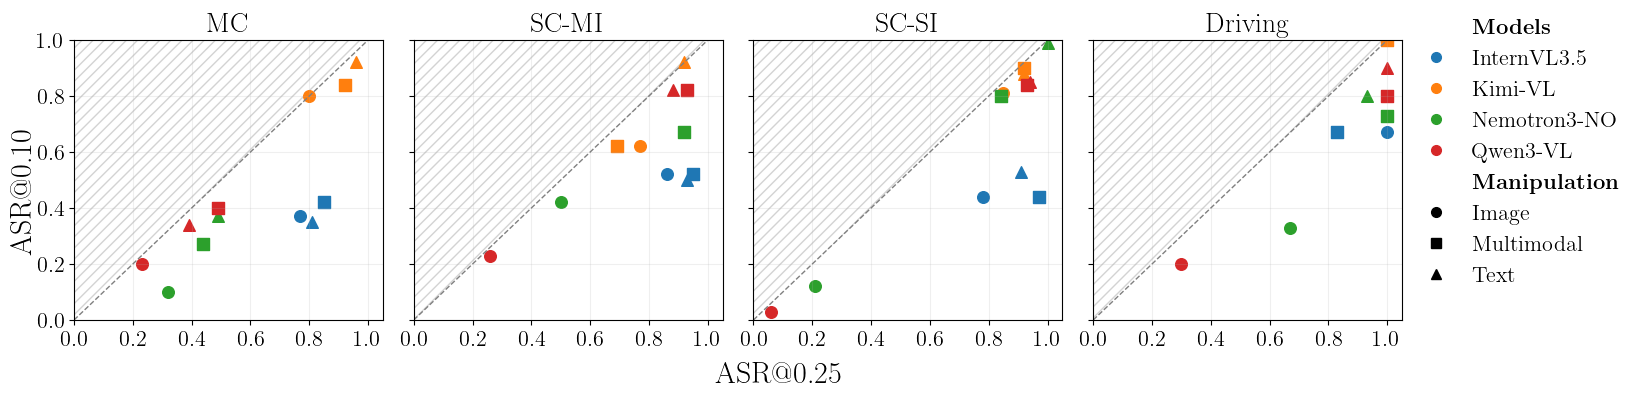

In [18]:
scenes = filtered["scene"].unique()
models = filtered["model"].unique()

markers = {
    "image": "o",
    "multi": "s",
    "text": "^",
}

# one consistent color per model
cmap = plt.get_cmap("tab10")
model_colors = {
    model: cmap(i)
    for i, model in enumerate(models)
}

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4),
    sharex=True,
    sharey=True,
    gridspec_kw={
        "wspace": 0.1
    }
)

axes = axes.flatten()
x = np.linspace(0, 1, 200)
for ax, scene in zip(axes, scenes):
    scene_df = filtered[filtered["scene"] == scene]

    ax.fill_between(
        x,
        x,
        1,
        facecolor="none",
        hatch="///",
        edgecolor="lightgray",
        linewidth=0
    )

    # boundary
    ax.plot(
        x, x,
        "--",
        color="gray",
        linewidth=1
    )
    for _, row in scene_df.iterrows():
        ax.scatter(
            float(row["frac25"]),
            float(row["frac10"]),
            color=model_colors[row["model"]],
            marker=markers[row["genome_mode"]],
            s=70,
        )

    ax.set_title(scene)
    ax.grid(alpha=0.2)

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.0)
    ax.set_xticks([0.0,0.2,0.4,0.6,0.8,1.0])

# shared labels
fig.supxlabel("ASR@0.25")
fig.supylabel("ASR@0.10")

from matplotlib.lines import Line2D

# --- model entries: color ---
model_handles = [
    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=model_colors[model],
        markeredgecolor=model_colors[model],
        markersize=7,
        label=MODEL_MAPPING[model],
    )
    for model in models
]

# --- genome mode entries: shape ---
mode_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle="none",
        color="black",
        markersize=7,
        label=MODALITY_ALIAS[mode],
    )
    for mode, marker in markers.items()
]

# optional separators / headings inside same legend
heading_model = Line2D([], [], linestyle="none", label=r"\textbf{Models}")
heading_mode = Line2D([], [], linestyle="none", label=r"\textbf{Manipulation}")

handles = (
    [heading_model]
    + model_handles
    + [heading_mode]
    + mode_handles
)

legend = fig.legend(
    handles=handles,
    loc="center left",
    bbox_to_anchor=(0.885, 0.6),
    frameon=False,
    handletextpad=0.6,
)

# Make heading labels bold
for text in legend.get_texts():
    if text.get_text() in ["Models", "Manipulation"]:
        text.set_weight("bold")

# reserve space on the right for legend
fig.subplots_adjust(
    left=0.06,
    right=0.89,
    bottom=0.18,
    top=0.88,
    wspace=0.07,
)

plt.savefig("figures/rq1_asr_comp.pdf", dpi=200, bbox_inches="tight")

In [19]:
from experiments._analysis import MetricTable

In [20]:
effectiveness_df["manipulation"] = effectiveness_df["genome_mode"].map(
    {
        "multi": r"\faImage\;+ \faFont",
        "image": r"\faImage",
        "text": r"\faFont",
    }
)
table = MetricTable(effectiveness_df, title="Effectiveness",
                    model_mapping= {k: v for k, v in MODEL_MAPPING.items() if k in effectiveness_df["model"].unique()},
                    scene_mapping={d: d for d in effectiveness_df["scene"].unique()},
                    metric_mapping={
                        "fail_rate": "BL Fail",
                        "manipulation": "Manipulation",
                        "frac25": "ASR@25",
                        "frac10": "ASR@10",
                        "ssim": r"SSIM$\uparrow$",
                        "ned": r"NED$\downarrow$",
                    },
                    )

In [21]:
print(table)

\begin{tabular}{llcccccc}
\toprule
Model & Scene & BL Fail & Manipulation & ASR@25 & ASR@10 & SSIM$\uparrow$ & NED$\downarrow$ \\
\midrule
\multirow{12}{*}{Qwen3-VL} & \multirow{3}{*}{Driving} & 0.82 & \faImage\;+ \faFont & 1.00 & 0.80 & $0.96 \pm 0.04$ & $0.00 \pm 0.00$ \\
 &  & 0.82 & \faImage & 0.30 & 0.20 & $0.95 \pm 0.04$ & --- \\
 &  & 0.82 & \faFont & 1.00 & 0.90 & --- & $0.09 \pm 0.14$ \\
\cmidrule(lr){2-8}
 & \multirow{3}{*}{MC} & 0.2 & \faImage\;+ \faFont & 0.49 & 0.40 & $0.94 \pm 0.05$ & $0.21 \pm 0.17$ \\
 &  & 0.2 & \faImage & 0.23 & 0.20 & $0.92 \pm 0.06$ & --- \\
 &  & 0.2 & \faFont & 0.39 & 0.34 & --- & $0.28 \pm 0.13$ \\
\cmidrule(lr){2-8}
 & \multirow{3}{*}{SC-MI} & 0.06 & \faImage\;+ \faFont & 0.93 & 0.82 & $0.94 \pm 0.06$ & $0.20 \pm 0.18$ \\
 &  & 0.06 & \faImage & 0.26 & 0.23 & $0.92 \pm 0.05$ & --- \\
 &  & 0.06 & \faFont & 0.88 & 0.82 & --- & $0.33 \pm 0.11$ \\
\cmidrule(lr){2-8}
 & \multirow{3}{*}{SC-SI} & 0.05 & \faImage\;+ \faFont & 0.93 & 0.84 & $0.96 \pm 0.